## 2.2 Hopeld network recall

In [ ]:
import numpy as np

# three memory

x1=np.array([-1,-1,1 ,-1 ,1 ,-1 ,-1 ,1])
x2=np.array([-1 ,-1, -1 ,-1 ,-1 ,1, -1, -1])
x3=np.array([-1, 1 ,1 ,-1 ,-1, 1 ,-1, 1])



# compute the weight matrix 
def weight_hop(X):
    p=len(X)
    n=len(X[0])
    W=np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            if i!=j:
                for x in X:
                    W[i][j]+=x[i]*x[j]
    return W/p

def update_patt(W,x):

    new_x=np.sign(W@x).astype(int)
    return new_x


def check_memory(W,X):
    for i,x in enumerate(X):
        print(x)
        new_x=update_patt(W,x)
        print(new_x)
        if np.array_equal(new_x, x):
            print(f"Pattern {i+1} memorized")
        else:
            print(f"Updated: {new_x}")
            print(f"Pattern {i+1} NOT memorized")

X=(x1,x2,x3)

W=weight_hop(X)

check_memory(W,X)









[-1 -1  1 -1  1 -1 -1  1]
[-1 -1  1 -1  1 -1 -1  1]
Pattern 1 memorized
[-1 -1 -1 -1 -1  1 -1 -1]
[-1 -1 -1 -1 -1  1 -1 -1]
Pattern 2 memorized
[-1  1  1 -1 -1  1 -1  1]
[-1  1  1 -1 -1  1 -1  1]
Pattern 3 memorized


## 3.1 Convergence and attractors

In [57]:
import matplotlib.pyplot as plt 

# distance hamming

def plot_hamming_with_cycle_detection(W, x_init, target_patterns, max_iter=100):
    current = x_init.copy()
    
    distances = {f'x{i+1}': [] for i in range(len(target_patterns))}
    history = [current.copy()]
    
    for iteration in range(max_iter):
        for i, target in enumerate(target_patterns):
            dist = np.sum(current != target)
            distances[f'x{i+1}'].append(dist)
        
        new_x = update_patt(W, current)
        
        history.append(new_x.copy())
        current = new_x
    
    # Plot
    plt.figure(figsize=(10, 5))
    for name, dists in distances.items():
        plt.plot(dists, marker='o', label=name)
    
    plt.xlabel('Iteration')
    plt.ylabel('Hamming Distance')
    plt.title('Distance evolution')
    plt.legend()
    plt.grid(True)
    plt.show()



Converegence of distorted patterns
Pattern:
[-1 -1  1 -1  1 -1 -1  1]
Nb of iterations:2


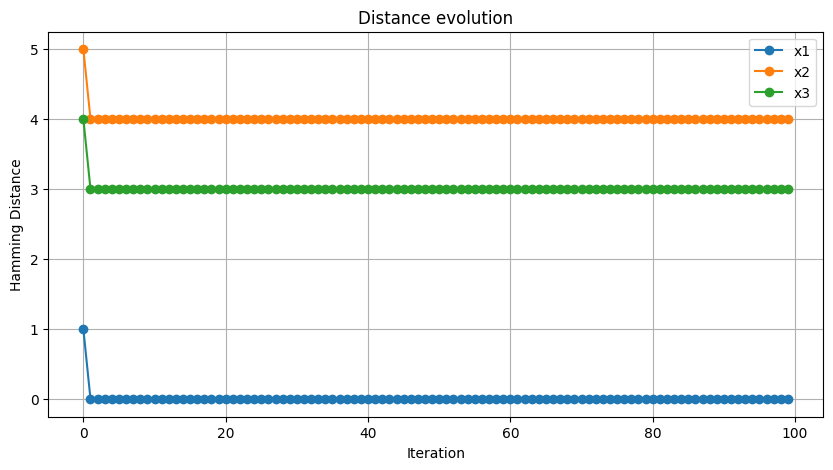

This is x1 (stored pattern)
Pattern:
Warning we have not converge yet
[ 1  1 -1 -1 -1  1 -1 -1]
Nb of iterations:1000


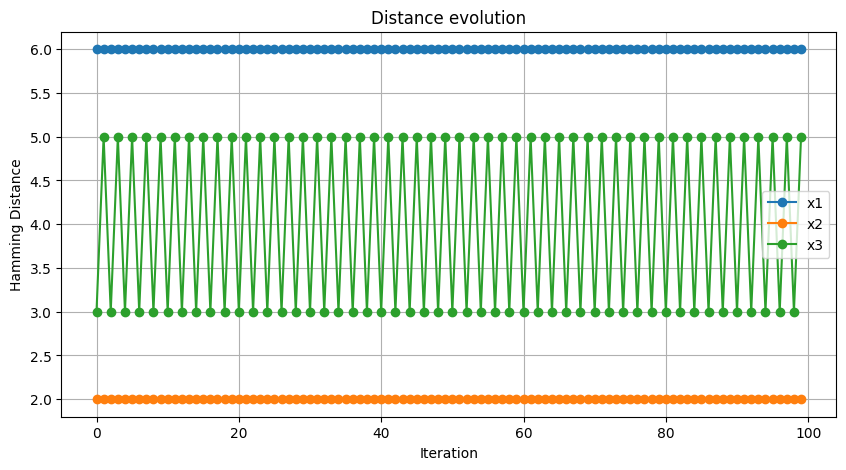

Spurious attractor (NOT stored)
Pattern:
Warning we have not converge yet
[-1 -1  1 -1  1  1 -1  1]
Nb of iterations:1000


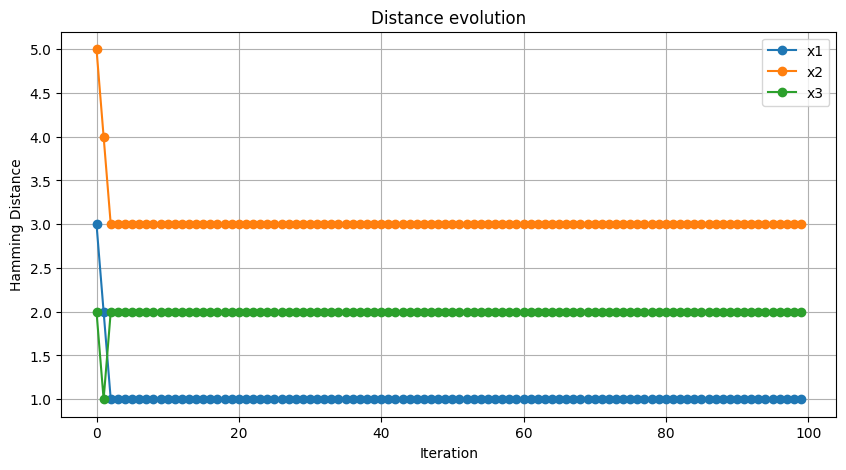

Spurious attractor (NOT stored)


In [58]:
# distorted patterns

x1d=np.array([ 1, -1 ,1 ,-1, 1, -1 ,-1 ,1])
x2d=np.array([ 1 ,1, -1 ,-1 ,-1 ,1 ,-1 ,-1])
x3d=np.array([ 1,1 ,1, -1 ,1 ,1 ,-1 ,1])

Xd=(x1d,x2d,x3d)

def asyn_hop(W, x,max_iter=1000):
    current = x.copy()
    L=[]
    for iter in range(1, max_iter + 1):
        new_x = update_patt(W, current)
        
        if np.array_equal(new_x, current):
            return new_x, iter
        
        current = new_x
    print("Warning we have not converge yet")
    return current, max_iter

    
    
# results    
print("Converegence of distorted patterns")

for x in Xd:
    print("Pattern:")
    new_x,iter=asyn_hop(W,x)
    print(new_x)
    print(f"Nb of iterations:{iter}")
    plot_hamming_with_cycle_detection(W, x,X, max_iter=100)
    if np.array_equal(new_x, x1):
        print("This is x1 (stored pattern)")
    elif np.array_equal(new_x, x2):
        print("This is x2 (stored pattern)")
    elif np.array_equal(new_x, x3):
        print("This is x3 (stored pattern) ")
    else:
        print("Spurious attractor (NOT stored)")
    


    




In [ ]:
def find_all_attractors(W, n=8):
    
    attractors = []
    
    for i in range(2**n):
        pattern = np.array([1 if (i >> j) & 1 else -1 for j in range(n)])
        
        updated = update_patt(W, pattern)
        
        if np.array_equal(pattern, updated):
            attractors.append(pattern)
    
    return attractors



attractors = find_all_attractors(W)

print(f"\nTotal number of attractors found: {len(attractors)}\n")

for i, attr in enumerate(attractors):
    print(f"Attractor {i+1}: {attr}")

    if np.array_equal(attr, x1):
        print("This is x1 (stored pattern)")
    elif np.array_equal(attr, x2):
        print("This is x2 (stored pattern)")
    elif np.array_equal(attr, x3):
        print("This is x3 (stored pattern) ")
    else:
        print("Spurious attractor (NOT stored)")


Total number of attractors found: 6

Attractor 1: [-1 -1 -1 -1 -1  1 -1 -1]
This is x2 (stored pattern)
Attractor 2: [ 1 -1 -1  1  1 -1  1 -1]
Spurious attractor (NOT stored)
Attractor 3: [ 1  1 -1  1 -1  1  1 -1]
Spurious attractor (NOT stored)
Attractor 4: [-1 -1  1 -1  1 -1 -1  1]
This is x1 (stored pattern)
Attractor 5: [-1  1  1 -1 -1  1 -1  1]
This is x3 (stored pattern) 
Attractor 6: [ 1  1  1  1  1 -1  1  1]
Spurious attractor (NOT stored)


Converegence of very distorted patterns
[ 1  1 -1  1 -1  1  1 -1]
Nb of iterations:1


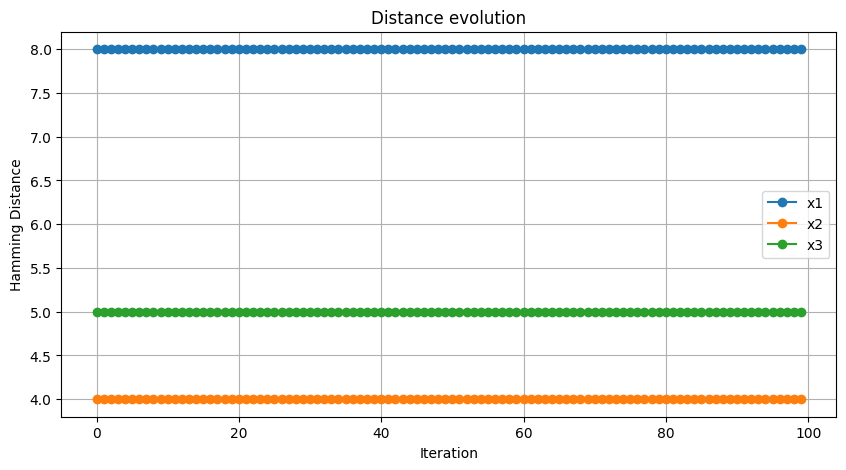

Spurious attractor (NOT stored)
[ 1  1  1  1  1 -1  1  1]
Nb of iterations:1


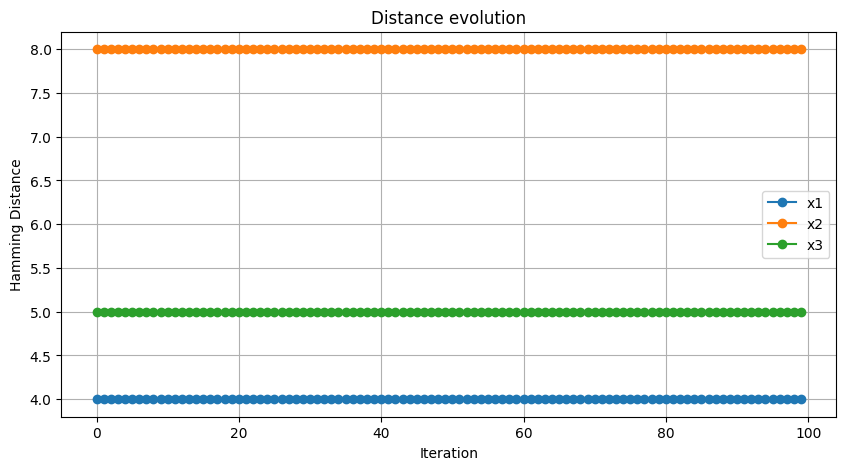

Spurious attractor (NOT stored)
[ 1 -1 -1  1  1 -1  1 -1]
Nb of iterations:1


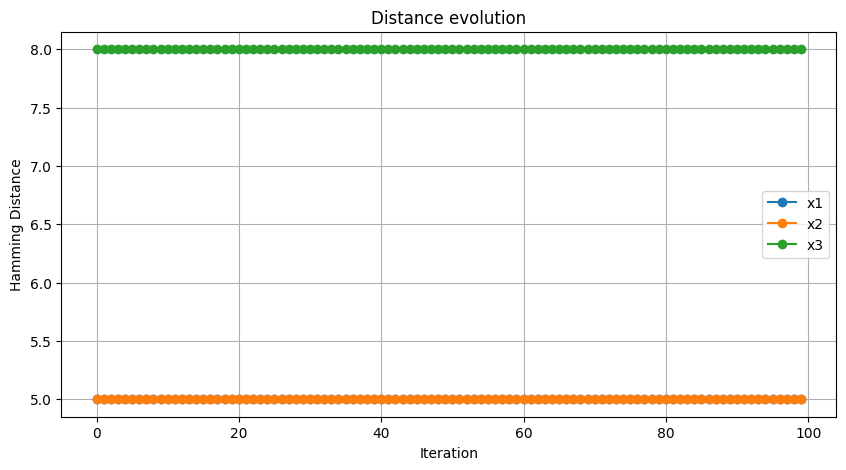

Spurious attractor (NOT stored)
[ 1 -1 -1  1  1 -1  1 -1]
Nb of iterations:3


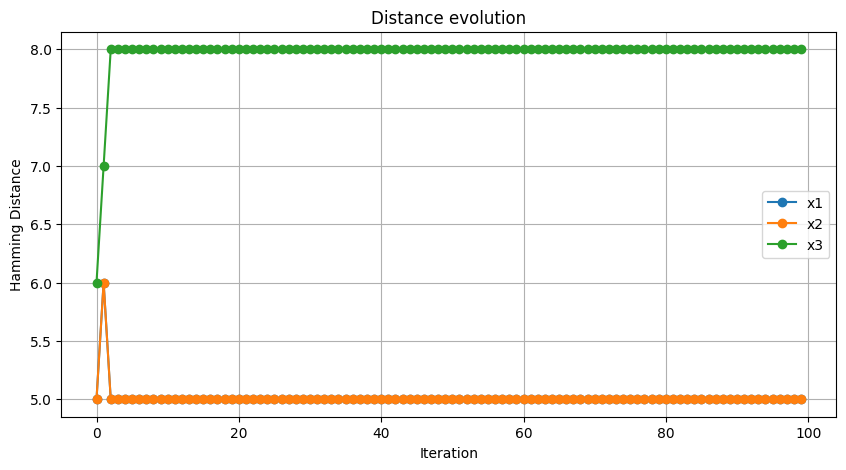

Spurious attractor (NOT stored)
[ 1  1 -1  1 -1  1  1 -1]
Nb of iterations:1


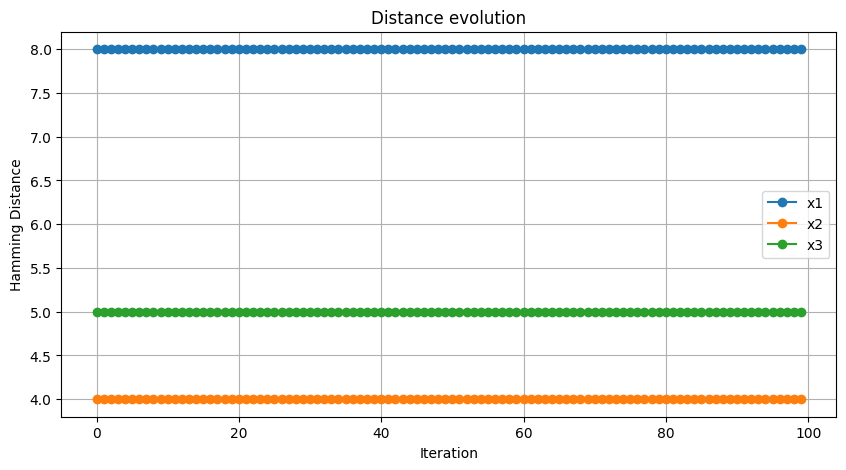

Spurious attractor (NOT stored)
[ 1  1  1  1  1 -1  1  1]
Nb of iterations:1


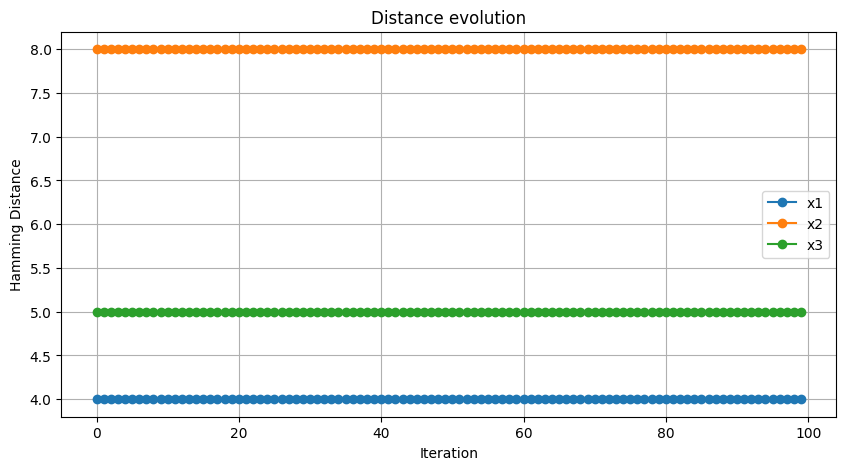

Spurious attractor (NOT stored)
[ 1 -1 -1  1  1 -1  1 -1]
Nb of iterations:1


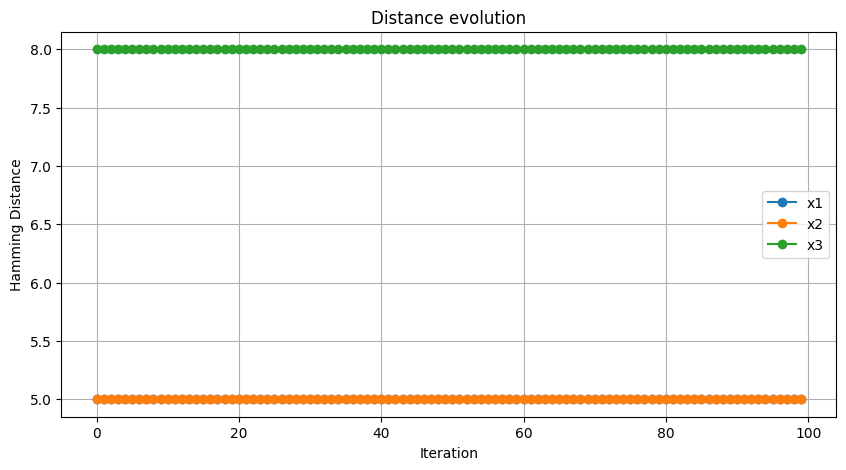

Spurious attractor (NOT stored)


In [60]:
# more dissimilar patterns

x1_very_dist = np.array([1, 1, -1, 1, -1, 1, 1, -1])
x2_very_dist = np.array([1, 1, 1, 1, 1, -1, 1, 1])
x3_very_dist = np.array([1, -1, -1, 1, 1, -1, 1, -1])
x_random = np.array([1, -1, 1, 1, -1, -1, 1, -1])
x1_inverse = -x1 
x2_inverse = -x2  
x3_inverse=-x3

X_very_dissimilar = [x1_very_dist, x2_very_dist, x3_very_dist, x_random, x1_inverse, x2_inverse, x3_inverse]

# results    
print("Converegence of very distorted patterns")

for x in X_very_dissimilar:
    new_x,iter=asyn_hop(W,x,100)
    print(new_x)
    print(f"Nb of iterations:{iter}")
    plot_hamming_with_cycle_detection(W, x,X, max_iter=100)

    if np.array_equal(new_x, x1):
        print("This is x1 (stored pattern)")
    elif np.array_equal(new_x, x2):
        print("This is x2 (stored pattern)")
    elif np.array_equal(new_x, x3):
        print("This is x3 (stored pattern) ")
    else:
        print("Spurious attractor (NOT stored)")

